![Citi-Bike-Nueva-York-azul](Citi-Bike-Nueva-York-azul.jpg)

## Exploratory Data Analysis (EDA) with New York Citi Bikes Dataset
 
### Introduction:

Here we will explore and analyze the New York Citi Bikes dataset, aiming to gain insights into bike rental patterns, trip durations, and user demographics. We will perform data cleaning, calculate statistics, and create visualizations using Python and popular data science libraries.

### Task 1: Data Cleaning and Basic Statistics

- Read the CSV file into a Pandas DataFrame named bikes.
- Print the column names of the DataFrame.
- Convert the "Start Time" and "Stop Time" columns to datetime format.
- Create a new DataFrame named bikes_df by dropping duplicate rows from bikes.
- Fill any missing values in bikes_df with 0.
- Convert the "Trip_Duration_in_min" column to numeric, replacing commas with blank space.
- Display the updated DataFrame bikes_df.
- Calculate and print the mean, median, maximum, and minimum trip durations.
- Exclude outliers (e.g., maximum values) in the "Trip_Duration_in_min" column and recalculate statistics.
- Calculate age statistics (mean, median, maximum, minimum) and print them.
- Create a table summarizing trip duration and age statistics, and display the table.

## Task 2: Data Analysis

- Calculate the top 10 most popular pick-up locations and display the result.
- Calculate the total trip duration for each age group and display the result.
- Calculate the number of rentals for each age group and display the result.
- Calculate the total number of bike rentals for each user type and weekday.
- Create a table with user type in the first column and weekdays as rows, highlighting the highest count and changing the color to grey.
- Calculate the number of one-time users and the percentage of one-time users.
- Calculate the percentage of subscribers and print both percentages.

## Task 3: Data Visualization

- Visualize the top 10 most popular pick-up locations using a horizontal bar chart.
- Visualize the average trip duration across different age groups using a bar chart.
- Visualize the number of rentals for each age group using a bar chart.
- Visualize the total number of bike rentals for each user type and weekday using an area chart.
- Create a scatter plot of age against trip duration.

## Task 4: Summary

Write the key insight you found analysing the data with actionable points answering the following questions: 

1. What are the most popular pick-up locations across the city for NY Citi Bike rental?
2. How does the average trip duration vary across different age groups?
3. Which age group rents the most bikes?
4. How does bike rental vary across the two user groups (one-time users vs long-term subscribers) on different days of the week?
5. Does user age impact the average bike trip duration?


### Task 1

In [66]:
import pandas as pd
import matplotlib.pyplot as plt

# Read the CSV file into a DataFrame
bikes = pd.read_csv("New York Citi Bikes_Raw Data - NYCitiBikes.csv")

# Print the column names of the DataFrame
print(bikes.columns)
print()

# Convert start time and stop time columns to datetime format
bikes['Start Time'] = pd.to_datetime(bikes['Start Time'])
bikes['Stop Time'] = pd.to_datetime(bikes['Stop Time'])

# Create a new DataFrame `bikes_df` by dropping duplicate rows from `bikes`
bikes_df = bikes.drop_duplicates()

# Fill any missing values in `bikes_df` with 0
bikes_df = bikes_df.dropna()

# Convert "Trip_Duration_in_min" column to numeric and replace commas with blank space
bikes_df["Trip_Duration_in_min"] = pd.to_numeric(bikes_df["Trip_Duration_in_min"].str.replace(',', ''))

# Display the updated DataFrame `bikes_df`
display(bikes_df.head())


# Calculate the mean, median, maximum, and minimum trip durations
trip_duration_mean_ = bikes_df["Trip_Duration_in_min"].mean()
trip_duration_median_ = bikes_df["Trip_Duration_in_min"].median()
trip_duration_max_ = bikes_df["Trip_Duration_in_min"].max()
trip_duration_min_ = bikes_df["Trip_Duration_in_min"].min()

# Print the statistics
print("Trip Duration Statistic:")
print("Trip_duration_mean:", round(trip_duration_mean_, 0))
print("Trip_duration_median:", round(trip_duration_median_, 0))
print("Trip_duration_min:", round(trip_duration_min_, 0))
print("Trip_duration_max:", round(trip_duration_max_, 0))


# Exclude the outlier (max value) in column "Trip_Duration_in_min"
bikes_df = bikes_df[bikes_df["Trip_Duration_in_min"] != trip_duration_max_]

# Recalculate the statistic data
trip_duration_mean = bikes_df["Trip_Duration_in_min"].mean()
trip_duration_median = bikes_df["Trip_Duration_in_min"].median()
trip_duration_max = bikes_df["Trip_Duration_in_min"].max()
trip_duration_min = bikes_df["Trip_Duration_in_min"].min()

# Print the updated statistic
print()
print("Updated Trip Duration Statistic:")
print("Trip duration mean:", round(trip_duration_mean, 0))
print("Trip duration median:", round(trip_duration_median, 0))
print("Trip duration min:", round(trip_duration_min, 0))
print("Trip duration max:", round(trip_duration_max, 0))


# Calculate age statistic
age_mean = bikes_df["Age"].mean()
age_median = bikes_df["Age"].median()
age_max = bikes_df["Age"].max()
age_min = bikes_df["Age"].min()

# Print age statistic
print()
print("Age statistic:")
print("Age mean:", round(age_mean, 0))
print("Age median:", round(age_median, 0))
print("Age min:", round(age_min, 0))
print("Age max:", round(age_max, 0))


# Create a table of trip duration and age statistics
statistics_table = pd.DataFrame({
    "Statistic": ["Mean", "Median", "Max", "Min"],
    "Trip Duration": [round(trip_duration_mean, 0), round(trip_duration_median, 0), round(trip_duration_max, 0), round(trip_duration_min, 0)],
    "Age": [round(age_mean, 0), round(age_median, 0), round(age_max, 0), round(age_min, 0)]
})

# Display the table
display(statistics_table)

Index(['Start Time', 'Stop Time', 'Start Station ID', 'Start Station Name',
       'End Station ID', 'End Station Name', 'Bike ID', 'User Type',
       'Birth Year', 'Age', 'Age Groups', 'Trip Duration',
       'Trip_Duration_in_min', 'Month', 'Season', 'Temperature', 'Weekday'],
      dtype='object')



,Start Time,Stop Time,Start Station ID,Start Station Name,End Station ID,End Station Name,Bike ID,User Type,Birth Year,Age,Age Groups,Trip Duration,Trip_Duration_in_min,Month,Season,Temperature,Weekday
0,2017-01-01 00:38:00,2017-01-01 01:03:00,3194,McGinley Square,3271,Danforth Light Rail,24668,Subscriber,1961,60,55-64,1513,25,1,Winter,10,Sunday
1,2017-01-01 01:47:00,2017-01-01 01:58:00,3183,Exchange Place,3203,Hamilton Park,26167,Subscriber,1993,28,25-34,639,11,1,Winter,10,Sunday
3,2017-01-01 01:56:00,2017-01-01 02:00:00,3186,Grove St PATH,3270,Jersey & 6th St,24604,Subscriber,1970,51,45-54,258,4,1,Winter,10,Sunday
4,2017-01-01 02:12:00,2017-01-01 02:23:00,3270,Jersey & 6th St,3206,Hilltop,24641,Subscriber,1978,43,35-44,663,11,1,Winter,10,Sunday
5,2017-01-01 02:22:00,2017-01-01 02:31:00,3212,Christ Hospital,3225,Baldwin at Montgomery,24520,Subscriber,1987,34,25-34,535,9,1,Winter,10,Sunday


Trip Duration Statistic:
Trip_duration_mean: 10.0
Trip_duration_median: 5.0
Trip_duration_min: 1
Trip_duration_max: 6515

Updated Trip Duration Statistic:
Trip duration mean: 9.0
Trip duration median: 5.0
Trip duration min: 1
Trip duration max: 3693

Age statistic:
Age mean: 42.0
Age median: 39.0
Age min: 22
Age max: 90


,Statistic,Trip Duration,Age
0,Mean,9.0,42.0
1,Median,5.0,39.0
2,Max,3693.0,90.0
3,Min,1.0,22.0


**Short code to get the same result  ⤵**

In [23]:
# Calculate descriptive statistics for the "Trip_Duration_in_min" column
trip_duration_statistic = bikes_df["Trip_Duration_in_min"].describe().round(0)

# Calculate descriptive statistics for the "Age" column
age_statistic = bikes_df["Age"].describe().round(0)

# Create a dataframe to store the statistics
statistic = pd.DataFrame([age_statistic, trip_duration_statistic]).transpose()

""" Optional formating"""

# Remove unnecessary rows from the dataframe
statistic.drop(["count","std","25%","75%"], axis=0, inplace=True)

# Rename the index "50%" to "median"
statistic.rename(index={"50%": "median"}, inplace=True)

# Reorder the rows in the dataframe
statistic = statistic.loc[["mean", "median", "min", "max"]]

# Rename the column "Trip_Duration_in_min" to "Trip Duration (min)"
statistic.rename(columns={"Trip_Duration_in_min": "Trip Duration (min)"}, inplace=True)

""" Optional formating"""

# Display the resulting dataframe
statistic

,Age,Trip Duration (min)
mean,42.0,9.0
median,39.0,5.0
min,22.0,1.0
max,90.0,3693.0


### Task 2:

In [65]:
# Calculate the top 10 most popular pick-up locations
pickup_locations_top = bikes_df['Start Station Name'].value_counts().head(10)
display(pickup_locations_top)

# Calculate the total trip duration for each age group
trip_duration = bikes_df.groupby('Age Groups')['Trip_Duration_in_min'].mean().round(0)
display(trip_duration)

# Calculate the number of rentals for each age group
most_rents = bikes_df["Age Groups"].value_counts()
display(most_rents)

# Calculate the total number of bike rentals for each user type and weekday
rental_vary_user = bikes_df.groupby(["User Type","Weekday"])['Bike ID'].count()

# Create a dataframe with user type in the first column and weekdays as rows
table_1 = rental_vary_user.unstack(level=0)

# Highlight the highest count in table_1 and change color to grey
highlighted_table_1 = table_1.style.highlight_max(axis=0).set_table_styles([{
    'selector': 'tr:hover',
    'props': [('background-color', 'yellow')]
}])
display(highlighted_table_1)

# Calculate the number of one-time users
one_time_users = (bikes_df["User Type"]=="One-time user").sum()

# Calculate the percentage of one-time users
one_time_users_percent = one_time_users/bikes_df["User Type"].count()*100

# Calculate the percentage of subscribers
subscribers = -one_time_users_percent + 1*100

# Print the percentage of subscribers
print("Subscribers:",str(subscribers.round(2)) + "%")

# Print the percentage of one-time users
print("One-time users:",str(one_time_users_percent.round(2))+"%")

Grove St PATH     2115
Exchange Place    1224
Sip Ave           1084
Hamilton Park     1069
Morris Canal       710
Newport PATH       651
City Hall          576
Van Vorst Park     530
Newark Ave         510
Warren St          481
Name: Start Station Name, dtype: int64

Age Groups
18-24    12.0
25-34     9.0
35-44     9.0
45-54     8.0
55-64     9.0
65-74     7.0
75+      49.0
Name: Trip_Duration_in_min, dtype: float64

35-44    7697
25-34    4002
45-54    2973
55-64    1447
65-74     615
75+        55
18-24      54
Name: Age Groups, dtype: int64

User Type,One-time user,Subscriber
Weekday,,
Friday,26,2422
Monday,52,2474
Saturday,93,1497
Sunday,64,1501
Thursday,19,2934
Tuesday,24,2436
Wednesday,39,3262


One-time users: 1.88%
Subscribers: 98.12%


### Task 3:

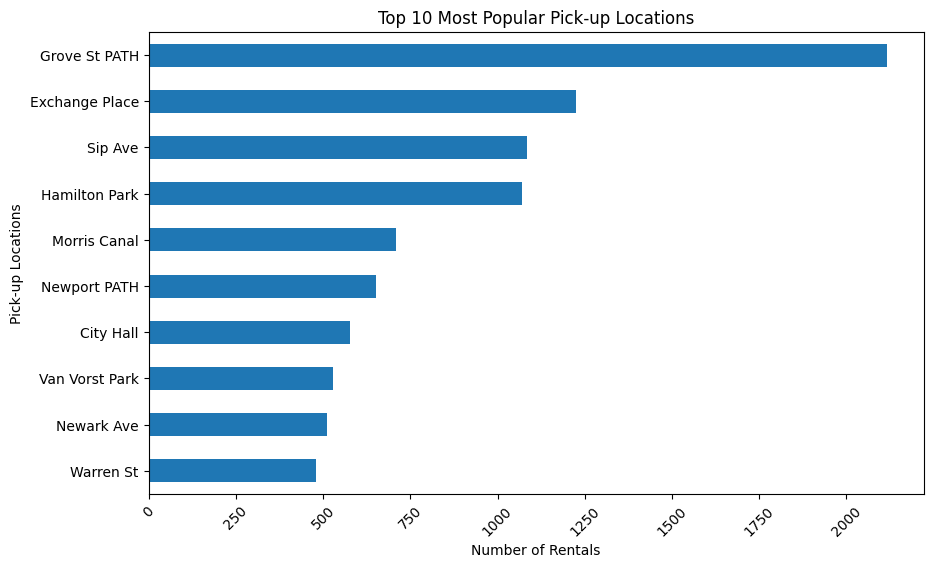

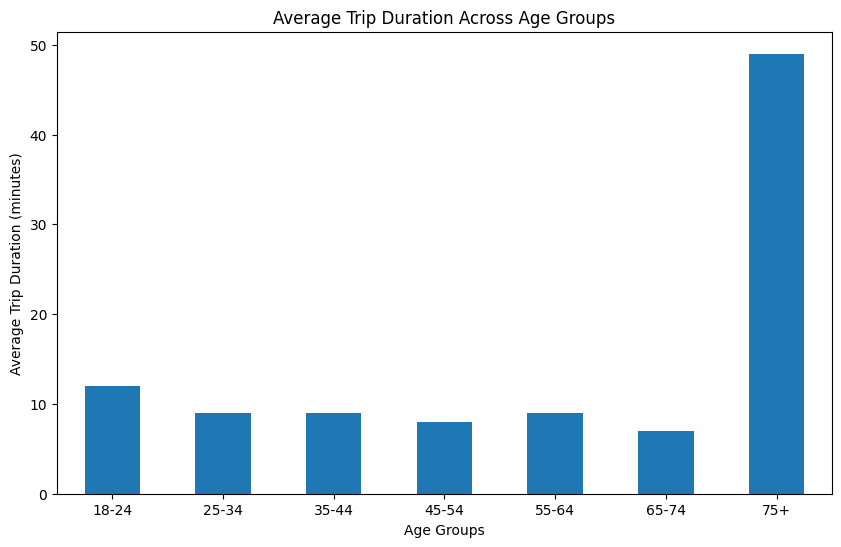

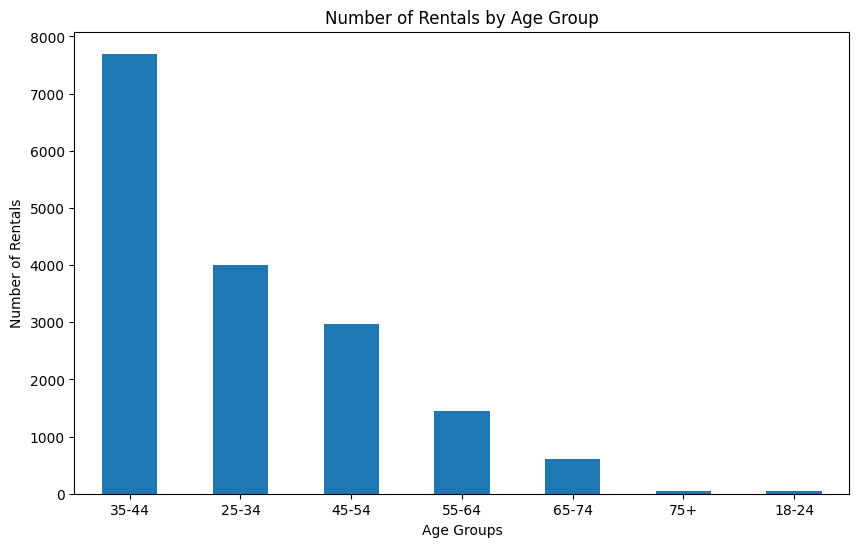

<Figure size 1000x600 with 0 Axes>

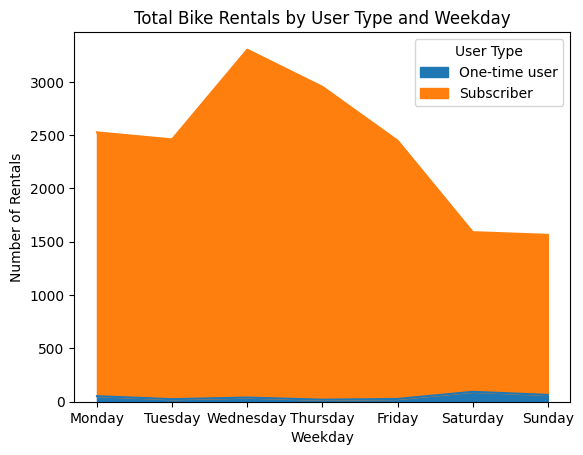

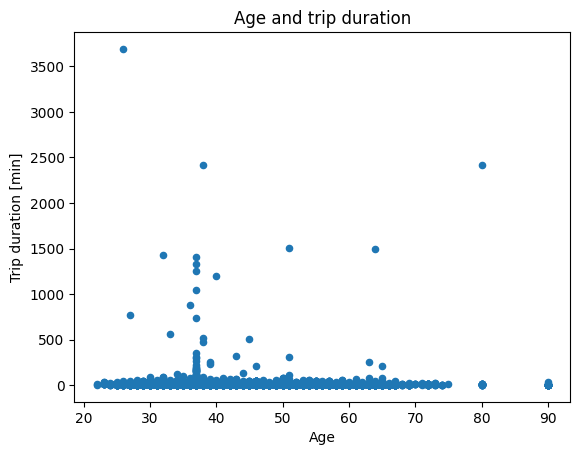

In [25]:
# Visualize the top 10 most popular pick-up locations
plt.figure(figsize=(10, 6))
pickup_locations_top.sort_values(ascending=True).plot(kind='barh')
plt.title('Top 10 Most Popular Pick-up Locations')
plt.xlabel('Number of Rentals')
plt.ylabel('Pick-up Locations')
plt.xticks(rotation=45)
plt.show()

# Visualize the average trip duration across different age groups
plt.figure(figsize=(10, 6))
trip_duration.plot(kind='bar')
plt.title('Average Trip Duration Across Age Groups')
plt.xlabel('Age Groups')
plt.ylabel('Average Trip Duration (minutes)')
plt.xticks(rotation=0)
plt.show()

# Visualize the number of rentals for each age group
plt.figure(figsize=(10, 6))
most_rents.plot(kind='bar')
plt.title('Number of Rentals by Age Group')
plt.xlabel('Age Groups')
plt.ylabel('Number of Rentals')
plt.xticks(rotation=0)
plt.show()

# Visualize the total number of bike rentals for each user type and weekday
plt.figure(figsize=(10, 6))
table_1.loc[['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']].plot(kind='area', stacked=True)
plt.title('Total Bike Rentals by User Type and Weekday')
plt.xlabel('Weekday')
plt.ylabel('Number of Rentals')
plt.xticks(rotation=0)
plt.show()

bikes_df.plot(x="Age",y='Trip_Duration_in_min', kind="scatter")
plt.title("Age and trip duration")
plt.xlabel("Age")
plt.ylabel("Trip duration [min]")
plt.show()

# Summary

## Insights:

- The mean trip duration is around 9 minutes, with a median of 5 minutes, indicating a right-skewed distribution.
- The dataset has a wide range of users, ages from 22 to 90, with a mean age of 42.

- Age seems to follow a normal distribution, with a median age of 39.

- Grove St PATH is the most popular pick-up location, followed by Exchange Place and Sip Ave.

- Trip duration varies across age groups, with the 75+ age group having the highest average trip duration.

- The 35-44 age group rents the most bikes, followed by the 25-34 and 45-54 age groups.

- Bike rentals are generally higher on weekdays compared to weekends, with subscribers contributing to a larger share of rentals (more the 98%). This suggests that bike rentals are more popular among regular users on weekdays (Wednesday is the peak day) .

- There is no clear correlation between age and trip duration, indicating that age may not be a significant factor in determining trip duration.

## Actionable Points
Based on the conclusions, the following actionable points can be suggested:

- Focus on optimizing resources and station placement in popular pick-up locations to meet the high demand for bike rentals.
 
- Develop targeted marketing campaigns to attract users from age groups with lower rental numbers, such as older age groups.

- Offer promotions or incentives to encourage bike rentals on weekends and attract more occasional users.
 
- Provide additional services or features that cater to the needs of subscribers, as they contribute to a significant portion of bike rentals.